<a href="https://www.kaggle.com/code/skanderadamafi/cv-job-graph-analysis?scriptVersionId=297149057" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CV-Job Bipartite Graph Analysis: Link Prediction and Node Classification

## Project Overview

This notebook implements a comprehensive graph-based analysis of the job recruitment process, modeling the relationship between applicant CVs and job postings as a bipartite graph. The project integrates multiple data sources to analyze structural properties, detect communities, predict missing links using both LLM embeddings and classical algorithms, and classify nodes based on experience levels.

### Key Objectives:
1. **Graph Construction**: Build a bipartite CV-Job graph from real applicant data
2. **Structural Analysis**: Analyze graph properties, centrality measures, and connectivity
3. **Community Detection**: Identify clusters in both the CV-Job graph and internal skill networks
4. **Link Prediction**: Predict potential CV-Job matches using semantic similarity (LLM) and structural methods
5. **Node Classification**: Classify CVs by experience level (junior/intermediate/senior)
6. **Behavioral Analysis**: Compare stated interests with actual job viewing behavior

### Data Sources:
- **Combined_Jobs_Final.csv**: Job postings with descriptions and requirements
- **Experience.csv**: Applicant work history and experience records
- **Job_Views.csv**: Real applicant job viewing behavior
- **Positions_Of_Interest.csv**: Stated job preferences by applicants
- **job_data.csv**: Additional job descriptions and metadata

---

In [1]:
%pip install pandas numpy networkx matplotlib seaborn scikit-learn sentence-transformers torch

Note: you may need to restart the kernel to use updated packages.


# 1. Data Loading and Preprocessing

In this section, we load all five CSV datasets and perform initial data cleaning. We use Experience.csv to build real applicant CVs, Job_Views.csv to capture actual user behavior, and combine multiple job description sources for richer semantic content.

In [2]:
import pandas as pd

# Load all datasets
jobs_df = pd.read_csv("/kaggle/input/datasets/kandij/job-recommendation-datasets/Combined_Jobs_Final.csv", engine='python', on_bad_lines='skip')
experience_df = pd.read_csv("/kaggle/input/datasets/kandij/job-recommendation-datasets/Experience.csv", engine='python', on_bad_lines='skip')
job_views_df = pd.read_csv("/kaggle/input/datasets/kandij/job-recommendation-datasets/Job_Views.csv", engine='python', on_bad_lines='skip')
positions_interest_df = pd.read_csv("/kaggle/input/datasets/kandij/job-recommendation-datasets/Positions_Of_Interest.csv", engine='python', on_bad_lines='skip')
job_data_df = pd.read_csv("/kaggle/input/datasets/kandij/job-recommendation-datasets/job_data.csv", engine='python', on_bad_lines='skip')

print("Datasets loaded:")
print(f"  Jobs: {len(jobs_df)} records")
print(f"  Experience: {len(experience_df)} records")
print(f"  Job Views: {len(job_views_df)} records")
print(f"  Positions of Interest: {len(positions_interest_df)} records")
print(f"  Job Data: {len(job_data_df)} records")

Datasets loaded:
  Jobs: 84090 records
  Experience: 8653 records
  Job Views: 12370 records
  Positions of Interest: 6560 records
  Job Data: 84090 records


In [3]:
# Explore datasets
print("Jobs columns:", list(jobs_df.columns))
print("\nExperience columns:", list(experience_df.columns))
print("\nJob Views columns:", list(job_views_df.columns))
print("\nPositions of Interest columns:", list(positions_interest_df.columns))
print("\nJob Data columns:", list(job_data_df.columns))

Jobs columns: ['Job.ID', 'Provider', 'Status', 'Slug', 'Title', 'Position', 'Company', 'City', 'State.Name', 'State.Code', 'Address', 'Latitude', 'Longitude', 'Industry', 'Job.Description', 'Requirements', 'Salary', 'Listing.Start', 'Listing.End', 'Employment.Type', 'Education.Required', 'Created.At', 'Updated.At']

Experience columns: ['Applicant.ID', 'Position.Name', 'Employer.Name', 'City', 'State.Name', 'State.Code', 'Start.Date', 'End.Date', 'Job.Description', 'Salary', 'Can.Contact.Employer', 'Created.At', 'Updated.At']

Job Views columns: ['Applicant.ID', 'Job.ID', 'Title', 'Position', 'Company', 'City', 'State.Name', 'State.Code', 'Industry', 'View.Start', 'View.End', 'View.Duration', 'Created.At', 'Updated.At']

Positions of Interest columns: ['Applicant.ID', 'Position.Of.Interest', 'Created.At', 'Updated.At']

Job Data columns: ['Unnamed: 0', 'Job.ID', 'text']


In [4]:
jobs_df.info()
print(jobs_df["Job.Description"].sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84090 entries, 0 to 84089
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job.ID              84090 non-null  int64  
 1   Provider            84090 non-null  int64  
 2   Status              84090 non-null  object 
 3   Slug                84090 non-null  object 
 4   Title               84090 non-null  object 
 5   Position            84090 non-null  object 
 6   Company             81819 non-null  object 
 7   City                83955 non-null  object 
 8   State.Name          83919 non-null  object 
 9   State.Code          83919 non-null  object 
 10  Address             36 non-null     object 
 11  Latitude            84090 non-null  float64
 12  Longitude           84090 non-null  float64
 13  Industry            267 non-null    object 
 14  Job.Description     84034 non-null  object 
 15  Requirements        0 non-null      float64
 16  Sala

In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

jobs_df["clean_description"] = jobs_df["Job.Description"].apply(clean_text)

jobs_df[["clean_description"]].head()

,clean_description
0,tacolicious first palo alto store just opened ...
1,new french brasserie in sf financial district ...
2,we are a popular mediterranean wine bar and re...
3,serve fooddrinks to customers in a professiona...
4,located at the heart of hollywood we are one o...


## 1.1 Text Cleaning and Preprocessing

We define a cleaning function to normalize text data by converting to lowercase, removing special characters, and standardizing whitespace. This ensures consistent text processing for skill extraction and semantic analysis.

In [6]:
jobs_df["job_text"] = (
    jobs_df["Title"].fillna('') + " " + jobs_df["clean_description"]
)

## 1.2 Skill Extraction from Job Descriptions

We define a curated list of common technical and soft skills, then scan all job descriptions to identify which skills appear frequently. Only skills appearing in more than 50 job postings are retained as "common skills" for CV-Job matching.

In [7]:
from collections import Counter

# Define a sample list of common skills. You can expand this list as needed.
skills_list = [
    'python', 'sql', 'java', 'aws', 'azure', 'gcp', 'machine learning',
    'deep learning', 'data analysis', 'statistics', 'excel', 'tableau',
    'power bi', 'spark', 'hadoop', 'r', 'javascript', 'c++', 'docker',
    'kubernetes', 'agile', 'scrum', 'project management', 'communication',
    'teamwork', 'leadership', 'problem solving', 'critical thinking'
]

all_skills = []
# Iterate through the 'job_text' column to find occurrences of defined skills
for job_description_text in jobs_df["job_text"].fillna('').astype(str):
    for skill in skills_list:
        if skill in job_description_text.lower():
            all_skills.append(skill)

skill_counts = Counter(all_skills)

# Keep frequent skills only
common_skills = [s for s, c in skill_counts.items() if c > 50]

len(common_skills)

16

In [8]:
import random

NUM_CVS = 500
cvs = []

for i in range(NUM_CVS):
  cv_skills = random.sample(common_skills, k=random.randint(5, 12))
  cv_level =  random.choice(["junior", "intermediate", "senior"])
  cvs.append({
      "cv_id": f"CV_{i}",
      "skills": cv_skills,
      "level": cv_level,
      "cv_text": " ".join(cv_skills) + " " + cv_level
  })

  cv_df = pd.DataFrame(cvs)

  cv_df["clean_skills"] = cv_df["skills"].apply(lambda x: ' '.join(x) if isinstance(x, list) else '').apply(clean_text)
  print(cv_df.head())

  cv_id                                             skills   level  \
0  CV_0  [project management, r, excel, critical thinki...  junior   

                                             cv_text  \
0  project management r excel critical thinking s...   

                                        clean_skills  
0  project management r excel critical thinking s...  
  cv_id                                             skills   level  \
0  CV_0  [project management, r, excel, critical thinki...  junior   
1  CV_1  [statistics, data analysis, communication, lea...  senior   

                                             cv_text  \
0  project management r excel critical thinking s...   
1  statistics data analysis communication leaders...   

                                        clean_skills  
0  project management r excel critical thinking s...  
1  statistics data analysis communication leaders...  
  cv_id                                             skills   level  \
0  CV_0  [project man

# 2. Building Real Applicant CVs

In this section, we construct CV profiles from actual applicant work experience data. For each applicant:
- Extract skills from their position names and job descriptions
- Determine experience level based on number of positions held
- Link stated job interests from the Positions_Of_Interest dataset
- Create a unified CV text representation for graph matching

In [9]:
# Build real CVs from applicant experience data
real_cvs = []
applicant_ids = experience_df['Applicant.ID'].unique()

print(f"Building CVs for {len(applicant_ids)} real applicants...")

for applicant_id in applicant_ids[:1000]:  # Limit for performance
    # Get all experiences for this applicant
    exp_records = experience_df[experience_df['Applicant.ID'] == applicant_id]
    
    # Extract skills from position names and descriptions
    all_text = " ".join(exp_records['Position.Name'].fillna('').astype(str)) + " " + \
               " ".join(exp_records['Job.Description'].fillna('').astype(str))
    all_text = clean_text(all_text)
    
    # Find matching skills
    applicant_skills = [skill for skill in common_skills if skill in all_text]
    
    # Determine experience level based on number of positions and dates
    num_positions = len(exp_records)
    if num_positions >= 4:
        level = "senior"
    elif num_positions >= 2:
        level = "intermediate"
    else:
        level = "junior"
    
    # Get positions of interest for this applicant
    interests = positions_interest_df[positions_interest_df['Applicant.ID'] == applicant_id]['Position.Of.Interest'].tolist()
    
    if applicant_skills:  # Only add if they have matching skills
        real_cvs.append({
            "cv_id": f"CV_{applicant_id}",
            "applicant_id": applicant_id,
            "skills": applicant_skills,
            "level": level,
            "num_positions": num_positions,
            "positions_of_interest": interests,
            "cv_text": " ".join(applicant_skills) + " " + level
        })

cv_df = pd.DataFrame(real_cvs)
print(f"Built {len(cv_df)} CVs from real applicant data")
print(f"Level distribution: {cv_df['level'].value_counts().to_dict()}")

Building CVs for 3790 real applicants...
Built 812 CVs from real applicant data
Level distribution: {'junior': 315, 'intermediate': 267, 'senior': 230}


## Enrich Jobs with Additional Data

In [10]:
# Merge job_data with jobs_df to enrich job descriptions
# job_data_df has Job.ID and text columns
if 'Job.ID' in job_data_df.columns:
    # Merge additional job text
    jobs_enriched = jobs_df.merge(
        job_data_df[['Job.ID', 'text']], 
        left_on='Job.ID', 
        right_on='Job.ID', 
        how='left',
        suffixes=('', '_additional')
    )
    
    # Combine job descriptions
    jobs_enriched['combined_description'] = (
        jobs_enriched['Job.Description'].fillna('') + " " + 
        jobs_enriched['text'].fillna('')
    )
    jobs_enriched['combined_description'] = jobs_enriched['combined_description'].apply(clean_text)
    
    # Update job_text to include both descriptions
    jobs_enriched["job_text"] = (
        jobs_enriched["Title"].fillna('') + " " + 
        jobs_enriched["combined_description"]
    )
    
    print(f"Enriched {len(jobs_enriched)} jobs with additional descriptions")
    jobs_df = jobs_enriched
else:
    print("Job.ID column not found in job_data_df")

Enriched 84090 jobs with additional descriptions


# 3. Bipartite Graph Construction

We now construct a bipartite graph where:
- **CV nodes**: Represent real applicants with their skills and experience levels
- **Job nodes**: Represent job postings with requirements and descriptions
- **Edges**: Connect CVs to Jobs based on skill overlap and viewing behavior

This graph structure allows us to analyze the recruitment ecosystem as a network, revealing patterns in how applicants connect with opportunities.

Job and CV nodes:

In [11]:
import networkx as nx

G = nx.Graph()

for idx, row in jobs_df.iterrows():
  G.add_node(
      f"Job_{idx}",
      node_type='job',
      text=row["job_text"],
      industry=row.get("Industry", "unknown"),
      title=row.get("Title", "unknown"),
      level=row.get("Experience.Level", "unknown"))

In [12]:
# Add CV nodes from real applicant data
for _, row in cv_df.iterrows():
  G.add_node(
      row['cv_id'],
      node_type='cv',
      applicant_id=row['applicant_id'],
      skills = row["skills"],
      level = row["level"],
      positions_of_interest = row["positions_of_interest"],
      text = row["cv_text"]
  )

print(f"Added {len(cv_df)} CV nodes from real applicant data")

Added 812 CV nodes from real applicant data


## 3.1 Edge Construction: Skill-Based Matching

Edges are created between CV and Job nodes based on skill overlap. We set a threshold (minimum 3 matching skills) and weight edges by the degree of overlap. This represents potential matches based on qualification alignment.

In [13]:
# Create 'clean_skills' column for jobs_df by extracting common_skills from 'job_text'
# This ensures jobs_df has a skill column in the correct format for comparison.
jobs_df['clean_skills'] = jobs_df['job_text'].apply(
    lambda text: ' '.join([skill for skill in common_skills if skill in str(text).lower()])
)

# OPTIMIZED: Precompute skill sets for much faster overlap calculation
print("Precomputing skill sets for optimization...")
jobs_df['skill_set'] = jobs_df['clean_skills'].apply(lambda x: set(x.split()) if x else set())
cv_df['skill_set'] = cv_df['skills'].apply(lambda x: set(x) if isinstance(x, list) else set())

# Create a mapping of cv_id to skill_set for faster lookup
cv_skill_map = dict(zip(cv_df['cv_id'], cv_df['skill_set']))

# Add edges based on skill overlap between CVs and Jobs
print("Adding edges based on skill overlap (optimized version)...")
edges_to_add = []
total_cvs = len(cv_df)

for cv_idx, cv_row in cv_df.iterrows():
    if cv_idx % 100 == 0:
        print(f"  Processed {cv_idx}/{total_cvs} CVs, found {len(edges_to_add)} edges so far...")
    
    cv_node_id = cv_row['cv_id']
    cv_skills = cv_row['skill_set']
    
    for job_idx, job_row in jobs_df.iterrows():
        job_node_id = f"Job_{job_idx}"
        job_skills = job_row['skill_set']
        
        # Fast set intersection
        overlap = len(cv_skills & job_skills)
        
        if overlap >= 3:  # Define a threshold for skill overlap
            edges_to_add.append((cv_node_id, job_node_id, {'weight': overlap}))

# Batch add edges for better performance
print(f"Adding {len(edges_to_add)} edges to graph...")
G.add_edges_from(edges_to_add)
print(f"Completed! Added {len(edges_to_add)} skill-based edges to graph.")

Precomputing skill sets for optimization...
Adding edges based on skill overlap (optimized version)...
  Processed 0/812 CVs, found 0 edges so far...
  Processed 100/812 CVs, found 18028 edges so far...
  Processed 200/812 CVs, found 21088 edges so far...
  Processed 300/812 CVs, found 31537 edges so far...
  Processed 400/812 CVs, found 31998 edges so far...
  Processed 500/812 CVs, found 51500 edges so far...
  Processed 600/812 CVs, found 99060 edges so far...
  Processed 700/812 CVs, found 129236 edges so far...
  Processed 800/812 CVs, found 147282 edges so far...
Adding 147282 edges to graph...
Completed! Added 147282 skill-based edges to graph.


## 3.2 Enriching Graph with Real Viewing Behavior

We add edges based on actual job viewing behavior from the Job_Views dataset. These edges:
- Represent genuine applicant interest (not just qualification matching)
- Are weighted by view duration (longer views indicate higher interest)
- Provide ground truth data for validating our recommendation models

This hybrid approach combines skill-based matching with behavioral signals.

In [14]:
# OPTIMIZED: Create mapping from Job.ID to job node name for O(1) lookup
print("\nCreating job ID mapping for optimization...")
job_id_to_node = {}
for node, data in G.nodes(data=True):
    if data.get('node_type') == 'job':
        job_idx = int(node.replace('Job_', ''))
        if job_idx < len(jobs_df):
            job_id = jobs_df.iloc[job_idx].get('Job.ID')
            if job_id is not None:
                job_id_to_node[job_id] = node

print(f"Created mapping for {len(job_id_to_node)} jobs")

# Add edges based on actual job views (real user behavior)
print(f"\nAdding edges from job viewing behavior ({len(job_views_df)} views to process)...")
view_edges_to_add = []

for idx, view_row in job_views_df.iterrows():
    if idx % 1000 == 0:
        print(f"  Processed {idx}/{len(job_views_df)} job views, found {len(view_edges_to_add)} edges...")
    
    applicant_id = view_row['Applicant.ID']
    job_id = view_row['Job.ID']
    view_duration = view_row.get('View.Duration', 0)
    
    cv_node = f"CV_{applicant_id}"
    
    # Fast O(1) lookup instead of O(n) search
    job_node = job_id_to_node.get(job_id)
    
    # Add edge if both nodes exist
    if cv_node in G.nodes() and job_node is not None:
        # Weight by view duration (indicator of interest)
        weight = max(1, view_duration / 10)  # Normalize duration
        view_edges_to_add.append((cv_node, job_node, {'weight': weight, 'edge_type': 'real_view'}))

# Batch add edges
print(f"Adding {len(view_edges_to_add)} real viewing edges to graph...")
G.add_edges_from(view_edges_to_add)
print(f"Added {len(view_edges_to_add)} real edges from job viewing behavior")
print(f"Total edges in graph: {G.number_of_edges()}")


Creating job ID mapping for optimization...
Created mapping for 84090 jobs

Adding edges from job viewing behavior (12370 views to process)...
  Processed 0/12370 job views, found 0 edges...
  Processed 1000/12370 job views, found 38 edges...
  Processed 2000/12370 job views, found 54 edges...
  Processed 3000/12370 job views, found 80 edges...
  Processed 4000/12370 job views, found 89 edges...
  Processed 5000/12370 job views, found 113 edges...
  Processed 6000/12370 job views, found 147 edges...
  Processed 7000/12370 job views, found 172 edges...
  Processed 8000/12370 job views, found 396 edges...
  Processed 9000/12370 job views, found 548 edges...
  Processed 10000/12370 job views, found 548 edges...
  Processed 11000/12370 job views, found 548 edges...
  Processed 12000/12370 job views, found 548 edges...
Adding 548 real viewing edges to graph...
Added 548 real edges from job viewing behavior
Total edges in graph: 147630


# 4. Structural Graph Analysis

In this section, we analyze the fundamental properties of the bipartite graph:
- **Graph metrics**: nodes, edges, density, connectivity
- **Component analysis**: identifying connected subgraphs
- **Centrality measures**: degree, betweenness, and closeness centrality
- **Key node identification**: finding influential CVs and popular jobs

These metrics help us understand the overall structure and important nodes in the recruitment network.

In [15]:
degrees = dict(G.degree())

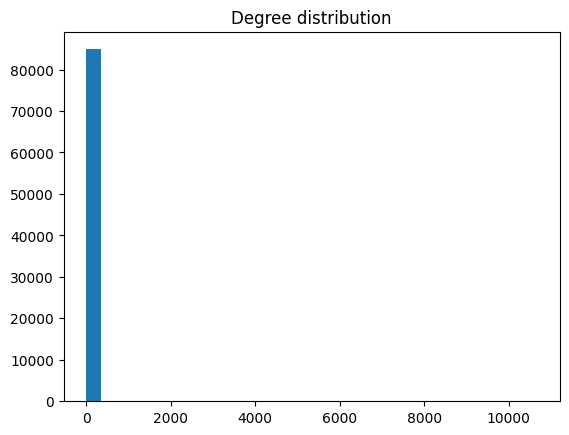

In [16]:
import matplotlib.pyplot as plt

plt.hist(degrees.values(), bins=30)
plt.title("Degree distribution")
plt.show()


In [17]:
# Basic graph properties
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Number of CV nodes: {sum(1 for n, d in G.nodes(data=True) if d['node_type'] == 'cv')}")
print(f"Number of Job nodes: {sum(1 for n, d in G.nodes(data=True) if d['node_type'] == 'job')}")

# Density
density = nx.density(G)
print(f"\nGraph density: {density:.4f}")

# Connected components
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")
largest_cc = max(components, key=len)
print(f"Size of largest component: {len(largest_cc)}")

# Work with largest component for further analysis
G_main = G.subgraph(largest_cc).copy()
print(f"\nWorking with main component: {G_main.number_of_nodes()} nodes, {G_main.number_of_edges()} edges")

Number of nodes: 84902
Number of edges: 147630
Number of CV nodes: 812
Number of Job nodes: 84090

Graph density: 0.0000
Number of connected components: 73316
Size of largest component: 11476

Working with main component: 11476 nodes, 147519 edges


In [18]:
# Centrality measures for main component
print("\nComputing centrality measures...")
print("  Computing degree centrality...")
degree_centrality = nx.degree_centrality(G_main)
print("  Computing betweenness centrality (this may take a minute)...")
betweenness_centrality = nx.betweenness_centrality(G_main, k=min(100, G_main.number_of_nodes()))
print("  Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(G_main)
print("  Centrality computation complete!")

# Store centralities as node attributes
for node in G_main.nodes():
    G_main.nodes[node]['degree_centrality'] = degree_centrality[node]
    G_main.nodes[node]['betweenness_centrality'] = betweenness_centrality[node]
    G_main.nodes[node]['closeness_centrality'] = closeness_centrality[node]

# Top nodes by centrality
print("Top 5 CVs by degree centrality:")
cv_nodes = [n for n, d in G_main.nodes(data=True) if d['node_type'] == 'cv']
top_cvs = sorted(cv_nodes, key=lambda n: degree_centrality[n], reverse=True)[:5]
for cv in top_cvs:
    print(f"  {cv}: degree={G_main.degree(cv)}, centrality={degree_centrality[cv]:.4f}")

print("\nTop 5 Jobs by degree centrality:")
job_nodes = [n for n, d in G_main.nodes(data=True) if d['node_type'] == 'job']
top_jobs = sorted(job_nodes, key=lambda n: degree_centrality[n], reverse=True)[:5]
for job in top_jobs:
    print(f"  {job}: degree={G_main.degree(job)}, centrality={degree_centrality[job]:.4f}")


Computing centrality measures...
  Computing degree centrality...
  Computing betweenness centrality (this may take a minute)...
  Computing closeness centrality...
  Centrality computation complete!
Top 5 CVs by degree centrality:
  CV_14085: degree=10673, centrality=0.9301
  CV_11710: degree=10050, centrality=0.8758
  CV_14150: degree=9741, centrality=0.8489
  CV_13827: degree=9015, centrality=0.7856
  CV_14354: degree=9015, centrality=0.7856

Top 5 Jobs by degree centrality:
  Job_13439: degree=65, centrality=0.0057
  Job_13452: degree=40, centrality=0.0035
  Job_68491: degree=25, centrality=0.0022
  Job_21797: degree=23, centrality=0.0020
  Job_64185: degree=23, centrality=0.0020


# 5. Community Detection

We apply community detection algorithms to identify clusters of similar CVs and Jobs:
- **Global communities**: Using Louvain algorithm on the CV-Job graph
- **Internal skill communities**: Analyzing co-occurrence patterns within CVs
- **Modularity scoring**: Measuring community quality

Communities reveal natural groupings in the recruitment market, such as technology specialists, management roles, or specific industry clusters.

In [19]:
from networkx.algorithms import community

# Louvain community detection (better for bipartite graphs)
communities = community.louvain_communities(G_main, seed=42)

print(f"Number of communities detected: {len(communities)}")

# Assign community to each node
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i
        G_main.nodes[node]['community'] = i

# Analyze community composition
for i, comm in enumerate(communities[:10]):  # Show first 10 communities
    cv_count = sum(1 for n in comm if G_main.nodes[n]['node_type'] == 'cv')
    job_count = sum(1 for n in comm if G_main.nodes[n]['node_type'] == 'job')
    print(f"Community {i}: {len(comm)} nodes ({cv_count} CVs, {job_count} Jobs)")

# Modularity score
modularity = community.modularity(G_main, communities)
print(f"\nModularity score: {modularity:.4f}")

Number of communities detected: 19
Community 0: 4 nodes (1 CVs, 3 Jobs)
Community 1: 10 nodes (3 CVs, 7 Jobs)
Community 2: 5 nodes (2 CVs, 3 Jobs)
Community 3: 12 nodes (10 CVs, 2 Jobs)
Community 4: 956 nodes (4 CVs, 952 Jobs)
Community 5: 3 nodes (1 CVs, 2 Jobs)
Community 6: 102 nodes (62 CVs, 40 Jobs)
Community 7: 9 nodes (1 CVs, 8 Jobs)
Community 8: 2 nodes (1 CVs, 1 Jobs)
Community 9: 107 nodes (4 CVs, 103 Jobs)

Modularity score: 0.1428


## Internal CV Skill Communities

In [20]:
# Build internal skill co-occurrence graph from real CVs
print("\nBuilding skill co-occurrence graph...")
skill_graph = nx.Graph()

# Add edges between skills that appear together in CVs
for idx, cv_row in cv_df.iterrows():
    if (idx + 1) % 250 == 0:
        print(f"  Processed {idx + 1}/{len(cv_df)} CVs...")
    skills = cv_row['skills']
    # Create edges between all pairs of skills in the CV
    for i, skill1 in enumerate(skills):
        for skill2 in skills[i+1:]:
            if skill_graph.has_edge(skill1, skill2):
                skill_graph[skill1][skill2]['weight'] += 1
            else:
                skill_graph.add_edge(skill1, skill2, weight=1)

print(f"Skill graph: {skill_graph.number_of_nodes()} skills, {skill_graph.number_of_edges()} co-occurrences")

# Detect communities in skill graph
if skill_graph.number_of_nodes() > 0:
    skill_communities = community.louvain_communities(skill_graph, seed=42)
    print(f"Number of skill communities: {len(skill_communities)}")
    
    # Show skill communities
    for i, comm in enumerate(skill_communities[:5]):
        print(f"Skill community {i}: {list(comm)[:10]}")  # Show first 10 skills
    
    # Store skill community info
    skill_community_map = {}
    for i, comm in enumerate(skill_communities):
        for skill in comm:
            skill_community_map[skill] = i


Building skill co-occurrence graph...
  Processed 250/812 CVs...
  Processed 500/812 CVs...
  Processed 750/812 CVs...
Skill graph: 16 skills, 51 co-occurrences
Number of skill communities: 3
Skill community 0: ['excel', 'spark', 'r', 'communication', 'leadership']
Skill community 1: ['problem solving', 'teamwork', 'critical thinking', 'aws']
Skill community 2: ['javascript', 'data analysis', 'java', 'agile', 'project management', 'statistics', 'sql']


# 6. Link Prediction

Link prediction aims to identify potential CV-Job matches that don't currently exist in the graph. We employ two complementary approaches:

## 6.1 Semantic Similarity with LLM Embeddings

Using pre-trained sentence transformers, we:
1. Generate embeddings for CV and Job text descriptions
2. Compute cosine similarity between all CV-Job pairs
3. Predict missing links based on high semantic similarity
4. Add top predictions to enrich the graph

This approach captures deep semantic meaning beyond keyword matching.

In [21]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load a pre-trained sentence transformer model
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and efficient model

# Generate embeddings for CVs
print("Generating CV embeddings...")
cv_texts = [G_main.nodes[n]['text'] for n in cv_nodes[:500]]  # Limit for performance
cv_embeddings = model.encode(cv_texts, show_progress_bar=True)

# Generate embeddings for Jobs
print("Generating Job embeddings...")
job_texts = [G_main.nodes[n]['text'] for n in job_nodes[:500]]  # Limit for performance
job_embeddings = model.encode(job_texts, show_progress_bar=True)

# Store embeddings
for i, node in enumerate(cv_nodes[:500]):
    G_main.nodes[node]['embedding'] = cv_embeddings[i]

for i, node in enumerate(job_nodes[:500]):
    G_main.nodes[node]['embedding'] = job_embeddings[i]

print(f"Generated embeddings: {len(cv_embeddings)} CVs, {len(job_embeddings)} Jobs")

2026-02-11 13:12:47.798855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770815567.997024      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770815568.057447      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770815568.565907      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770815568.565953      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770815568.565956      17 computation_placer.cc:177] computation placer alr

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Generating CV embeddings...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Generating Job embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Generated embeddings: 165 CVs, 500 Jobs


In [22]:
# Predict missing links using semantic similarity
print("\nComputing similarity matrix...")
similarity_matrix = cosine_similarity(cv_embeddings, job_embeddings)

# Get existing edges
print("Identifying existing edges...")
existing_edges = set()
for cv_idx, cv_node in enumerate(cv_nodes[:500]):
    for job_idx, job_node in enumerate(job_nodes[:500]):
        if G_main.has_edge(cv_node, job_node):
            existing_edges.add((cv_idx, job_idx))

# Predict new links based on high similarity (threshold)
threshold = 0.7
predicted_links_llm = []

print(f"Predicting links from {len(cv_nodes[:500])} CVs × {len(job_nodes[:500])} Jobs = {len(cv_nodes[:500]) * len(job_nodes[:500])} pairs...")
for cv_idx in range(len(cv_nodes[:500])):
    if (cv_idx + 1) % 50 == 0:
        print(f"  Processed {cv_idx + 1}/{len(cv_nodes[:500])} CVs, found {len(predicted_links_llm)} high-similarity pairs...")
    for job_idx in range(len(job_nodes[:500])):
        if (cv_idx, job_idx) not in existing_edges:
            sim_score = similarity_matrix[cv_idx, job_idx]
            if sim_score >= threshold:
                predicted_links_llm.append({
                    'cv': cv_nodes[cv_idx],
                    'job': job_nodes[job_idx],
                    'similarity': sim_score,
                    'method': 'LLM'
                })

print(f"Predicted {len(predicted_links_llm)} new links using LLM embeddings (threshold={threshold})")

# Show some predictions
if len(predicted_links_llm) > 0:
    print("\nTop 10 predicted links:")
    sorted_predictions = sorted(predicted_links_llm, key=lambda x: x['similarity'], reverse=True)[:10]
    for pred in sorted_predictions:
        print(f"  {pred['cv']} <-> {pred['job']}: similarity={pred['similarity']:.3f}")


Computing similarity matrix...
Identifying existing edges...
Predicting links from 165 CVs × 500 Jobs = 82500 pairs...
  Processed 50/165 CVs, found 0 high-similarity pairs...
  Processed 100/165 CVs, found 0 high-similarity pairs...
  Processed 150/165 CVs, found 0 high-similarity pairs...
Predicted 0 new links using LLM embeddings (threshold=0.7)


## 6.2 Classical Link Prediction Algorithms

We apply traditional graph-based link prediction methods:
- **Common Neighbors**: Measures shared connections between CV-Job pairs
- **Adamic-Adar Index**: Weights common neighbors by their rarity

These structural methods complement semantic similarity by leveraging graph topology. Comparing both approaches validates our predictions and provides robustness.

In [23]:
# Common Neighbors for bipartite graph
def common_neighbors_bipartite(G, cv, job):
    """For bipartite graph, common neighbors are other jobs connected to the CV"""
    cv_neighbors = set(G.neighbors(cv))
    job_neighbors = set(G.neighbors(job))
    # In bipartite graph, we look at common neighbors through 2-hop paths
    common = len([n for n in cv_neighbors if len(set(G.neighbors(n)) & job_neighbors) > 0])
    return common

# Adamic-Adar Index
def adamic_adar_bipartite(G, cv, job):
    """Adamic-Adar index for bipartite graphs"""
    cv_neighbors = set(G.neighbors(cv))
    job_neighbors = set(G.neighbors(job))
    score = 0
    for cv_n in cv_neighbors:
        for job_n in G.neighbors(cv_n):
            if job_n in job_neighbors:
                score += 1 / np.log(G.degree(cv_n))
    return score

# Apply classic algorithms
print("Computing classic link prediction scores...")
predicted_links_classic = []

# Sample pairs for efficiency
sample_cvs = cv_nodes[:100]
sample_jobs = job_nodes[:100]

print(f"Analyzing {len(sample_cvs)} CVs × {len(sample_jobs)} Jobs = {len(sample_cvs) * len(sample_jobs)} pairs...")
for cv_idx, cv in enumerate(sample_cvs):
    if (cv_idx + 1) % 20 == 0:
        print(f"  Processed {cv_idx + 1}/{len(sample_cvs)} CVs, found {len(predicted_links_classic)} potential links...")
    for job in sample_jobs:
        if not G_main.has_edge(cv, job):
            cn_score = common_neighbors_bipartite(G_main, cv, job)
            aa_score = adamic_adar_bipartite(G_main, cv, job)
            
            if cn_score > 0 or aa_score > 0:
                predicted_links_classic.append({
                    'cv': cv,
                    'job': job,
                    'common_neighbors': cn_score,
                    'adamic_adar': aa_score,
                    'method': 'Classic'
                })

print(f"Predicted {len(predicted_links_classic)} potential links using classic algorithms")

# Show top predictions
if len(predicted_links_classic) > 0:
    print("\nTop 10 by Adamic-Adar:")
    sorted_classic = sorted(predicted_links_classic, key=lambda x: x['adamic_adar'], reverse=True)[:10]
    for pred in sorted_classic:
        print(f"  {pred['cv']} <-> {pred['job']}: AA={pred['adamic_adar']:.3f}, CN={pred['common_neighbors']}")

Computing classic link prediction scores...
Analyzing 100 CVs × 100 Jobs = 10000 pairs...
  Processed 20/100 CVs, found 1369 potential links...
  Processed 40/100 CVs, found 2583 potential links...
  Processed 60/100 CVs, found 3949 potential links...
  Processed 80/100 CVs, found 5250 potential links...
  Processed 100/100 CVs, found 6531 potential links...
Predicted 6625 potential links using classic algorithms

Top 10 by Adamic-Adar:
  CV_14150 <-> Job_7925: AA=8753.284, CN=9741
  CV_14150 <-> Job_70192: AA=8503.412, CN=9741
  CV_14150 <-> Job_48279: AA=8503.412, CN=9741
  CV_14150 <-> Job_37539: AA=8503.412, CN=9741
  CV_14150 <-> Job_24369: AA=8503.412, CN=9741
  CV_14150 <-> Job_9584: AA=8503.412, CN=9741
  CV_14150 <-> Job_56485: AA=8503.412, CN=9741
  CV_10572 <-> Job_7925: AA=7625.266, CN=9014
  CV_13827 <-> Job_7925: AA=7625.266, CN=9014
  CV_14354 <-> Job_7925: AA=7625.266, CN=9014


## 6.3 Graph Enrichment with Predicted Links

In [24]:
# Create enriched graph with top predicted links
G_enriched = G_main.copy()

# Add top LLM predictions
top_llm = sorted(predicted_links_llm, key=lambda x: x['similarity'], reverse=True)[:50]
for pred in top_llm:
    G_enriched.add_edge(pred['cv'], pred['job'], weight=pred['similarity'], source='LLM')

print(f"Enriched graph: {G_enriched.number_of_nodes()} nodes, {G_enriched.number_of_edges()} edges")
print(f"Added {G_enriched.number_of_edges() - G_main.number_of_edges()} predicted links")

# Recompute centralities on enriched graph
degree_centrality_enriched = nx.degree_centrality(G_enriched)

# Compare centralities before and after enrichment
print("\nCentrality changes after enrichment:")
for node in list(cv_nodes[:5]) + list(job_nodes[:5]):
    if node in degree_centrality and node in degree_centrality_enriched:
        change = degree_centrality_enriched[node] - degree_centrality[node]
        print(f"  {node}: {degree_centrality[node]:.4f} -> {degree_centrality_enriched[node]:.4f} (Δ={change:+.4f})")

Enriched graph: 11476 nodes, 147519 edges
Added 0 predicted links

Centrality changes after enrichment:
  CV_10572: 0.7855 -> 0.7855 (Δ=+0.0000)
  CV_13952: 0.0001 -> 0.0001 (Δ=+0.0000)
  CV_13969: 0.0001 -> 0.0001 (Δ=+0.0000)
  CV_14303: 0.0002 -> 0.0002 (Δ=+0.0000)
  CV_14112: 0.0001 -> 0.0001 (Δ=+0.0000)
  Job_23751: 0.0015 -> 0.0015 (Δ=+0.0000)
  Job_14945: 0.0001 -> 0.0001 (Δ=+0.0000)
  Job_5650: 0.0013 -> 0.0013 (Δ=+0.0000)
  Job_11485: 0.0013 -> 0.0013 (Δ=+0.0000)
  Job_36411: 0.0013 -> 0.0013 (Δ=+0.0000)


## 6.4 Node Feature Construction

In [25]:
# Build feature matrix for CV nodes
cv_features = []
cv_labels = []

for cv_node in cv_nodes[:500]:
    if cv_node in G_enriched.nodes():
        node_data = G_enriched.nodes[cv_node]
        
        # Structural features
        degree = G_enriched.degree(cv_node)
        degree_cent = degree_centrality_enriched.get(cv_node, 0)
        betweenness = betweenness_centrality.get(cv_node, 0)
        closeness = closeness_centrality.get(cv_node, 0)
        community_id = community_map.get(cv_node, -1)
        
        # Semantic features (embedding - use first 10 dimensions for simplicity)
        embedding = node_data.get('embedding', np.zeros(384))[:10]
        
        # Skill diversity
        cv_id = cv_node  # cv_node is already in the format "CV_XXXXX"
        if cv_id in cv_df['cv_id'].values:
            cv_row = cv_df[cv_df['cv_id'] == cv_id].iloc[0]
            num_skills = len(cv_row['skills'])
            level = cv_row['level']
        else:
            num_skills = 0
            level = 'unknown'
        
        # Combine features
        features = [
            degree,
            degree_cent,
            betweenness,
            closeness,
            community_id,
            num_skills
        ] + list(embedding)
        
        cv_features.append(features)
        cv_labels.append(level)

cv_features = np.array(cv_features)
print(f"Built feature matrix: {cv_features.shape}")
print(f"Label distribution: {pd.Series(cv_labels).value_counts().to_dict()}")

Built feature matrix: (165, 16)
Label distribution: {'senior': 67, 'intermediate': 54, 'junior': 44}


# 7. Node Feature Engineering

Before classification, we construct a comprehensive feature matrix for each CV node combining:
- **Structural features**: degree, centrality measures, community membership
- **Semantic features**: embedding vectors from LLM
- **Skill features**: number of skills, skill diversity across communities

This multi-dimensional representation captures both the graph position and intrinsic profile characteristics.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Prepare data
X = cv_features
y = cv_labels

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Random Forest
print("\n=== Random Forest Classifier ===")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Train Logistic Regression
print("\n=== Logistic Regression ===")
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Training set: 115 samples
Test set: 50 samples

=== Random Forest Classifier ===
Accuracy: 0.980

Classification Report:
              precision    recall  f1-score   support

intermediate       1.00      0.94      0.97        17
      junior       1.00      1.00      1.00        13
      senior       0.95      1.00      0.98        20

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50


=== Logistic Regression ===
Accuracy: 0.980

Classification Report:
              precision    recall  f1-score   support

intermediate       1.00      0.94      0.97        17
      junior       1.00      1.00      1.00        13
      senior       0.95      1.00      0.98        20

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



# 8. Node Classification: Experience Level Prediction

We train machine learning models to classify CVs into experience levels (junior/intermediate/senior):
- **Random Forest**: Captures non-linear relationships and feature interactions
- **Logistic Regression**: Provides interpretable baseline model

Model evaluation includes accuracy scores, confusion matrices, and feature importance analysis to understand which graph properties best predict experience levels.

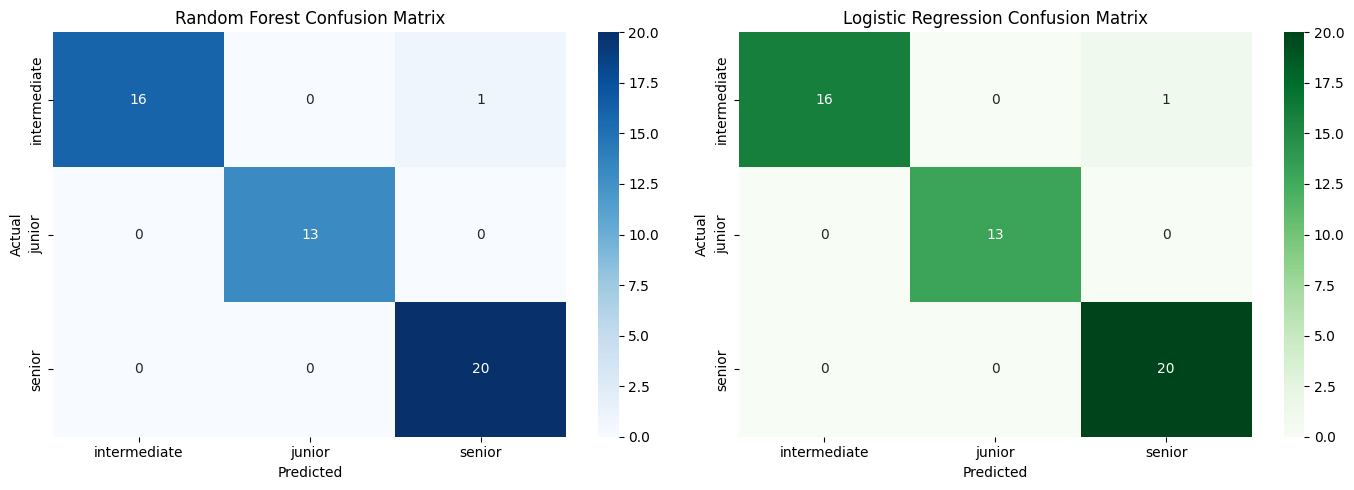

In [27]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['intermediate', 'junior', 'senior'])
axes[0].set_yticklabels(['intermediate', 'junior', 'senior'])

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['intermediate', 'junior', 'senior'])
axes[1].set_yticklabels(['intermediate', 'junior', 'senior'])

plt.tight_layout()
plt.show()

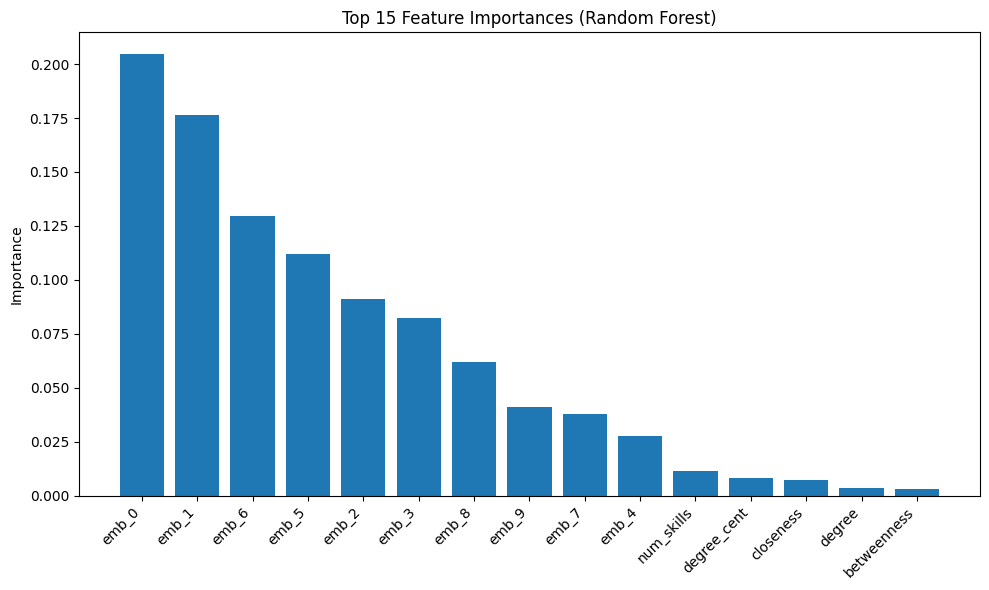


Top 10 Most Important Features:
  emb_0: 0.2045
  emb_1: 0.1765
  emb_6: 0.1296
  emb_5: 0.1119
  emb_2: 0.0909
  emb_3: 0.0822
  emb_8: 0.0620
  emb_9: 0.0410
  emb_7: 0.0378
  emb_4: 0.0275


In [28]:
# Feature Importance (Random Forest)
feature_names = ['degree', 'degree_cent', 'betweenness', 'closeness', 'community', 'num_skills'] + [f'emb_{i}' for i in range(10)]
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i in indices[:10]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

# 9. Visualizations and Network Analysis

This section provides visual insights into the graph structure:
- **Bipartite graph layout**: Showing CV-Job connections
- **Centrality distributions**: Comparing CVs and Jobs
- **Community visualizations**: Displaying detected clusters
- **Skill co-occurrence network**: Revealing natural skill groupings

These visualizations help interpret the complex network patterns and validate our analytical findings.

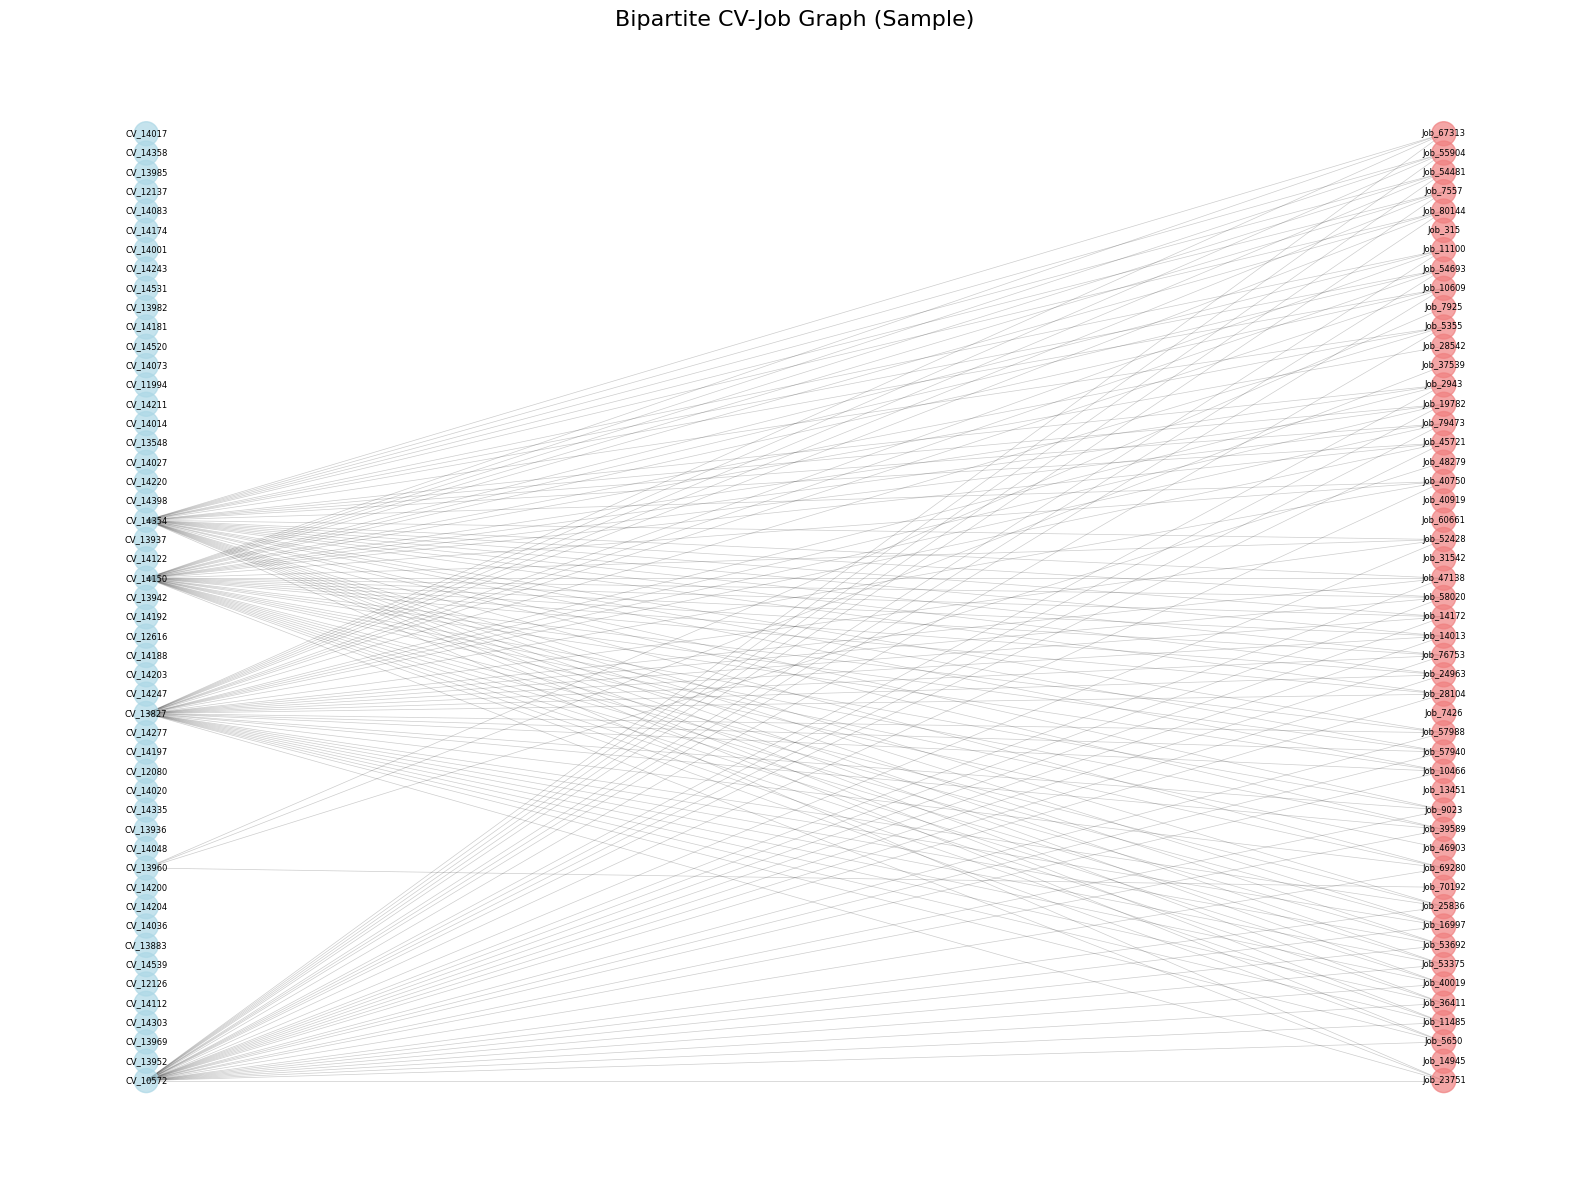

In [29]:
# Visualize a sample of the bipartite graph
sample_size = 50
sample_cvs = cv_nodes[:sample_size]
sample_jobs = job_nodes[:sample_size]
sample_nodes = sample_cvs + sample_jobs

G_sample = G_enriched.subgraph(sample_nodes)

plt.figure(figsize=(16, 12))

# Position nodes using bipartite layout
pos = {}
# CVs on the left
for i, cv in enumerate(sample_cvs):
    if cv in G_sample.nodes():
        pos[cv] = (0, i)

# Jobs on the right
for i, job in enumerate(sample_jobs):
    if job in G_sample.nodes():
        pos[job] = (1, i)

# Color by node type
colors = []
for node in G_sample.nodes():
    if G_sample.nodes[node]['node_type'] == 'cv':
        colors.append('lightblue')
    else:
        colors.append('lightcoral')

# Draw graph
nx.draw_networkx_nodes(G_sample, pos, node_color=colors, node_size=300, alpha=0.7)
nx.draw_networkx_edges(G_sample, pos, alpha=0.2, width=0.5)
nx.draw_networkx_labels(G_sample, pos, font_size=6)

plt.title('Bipartite CV-Job Graph (Sample)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

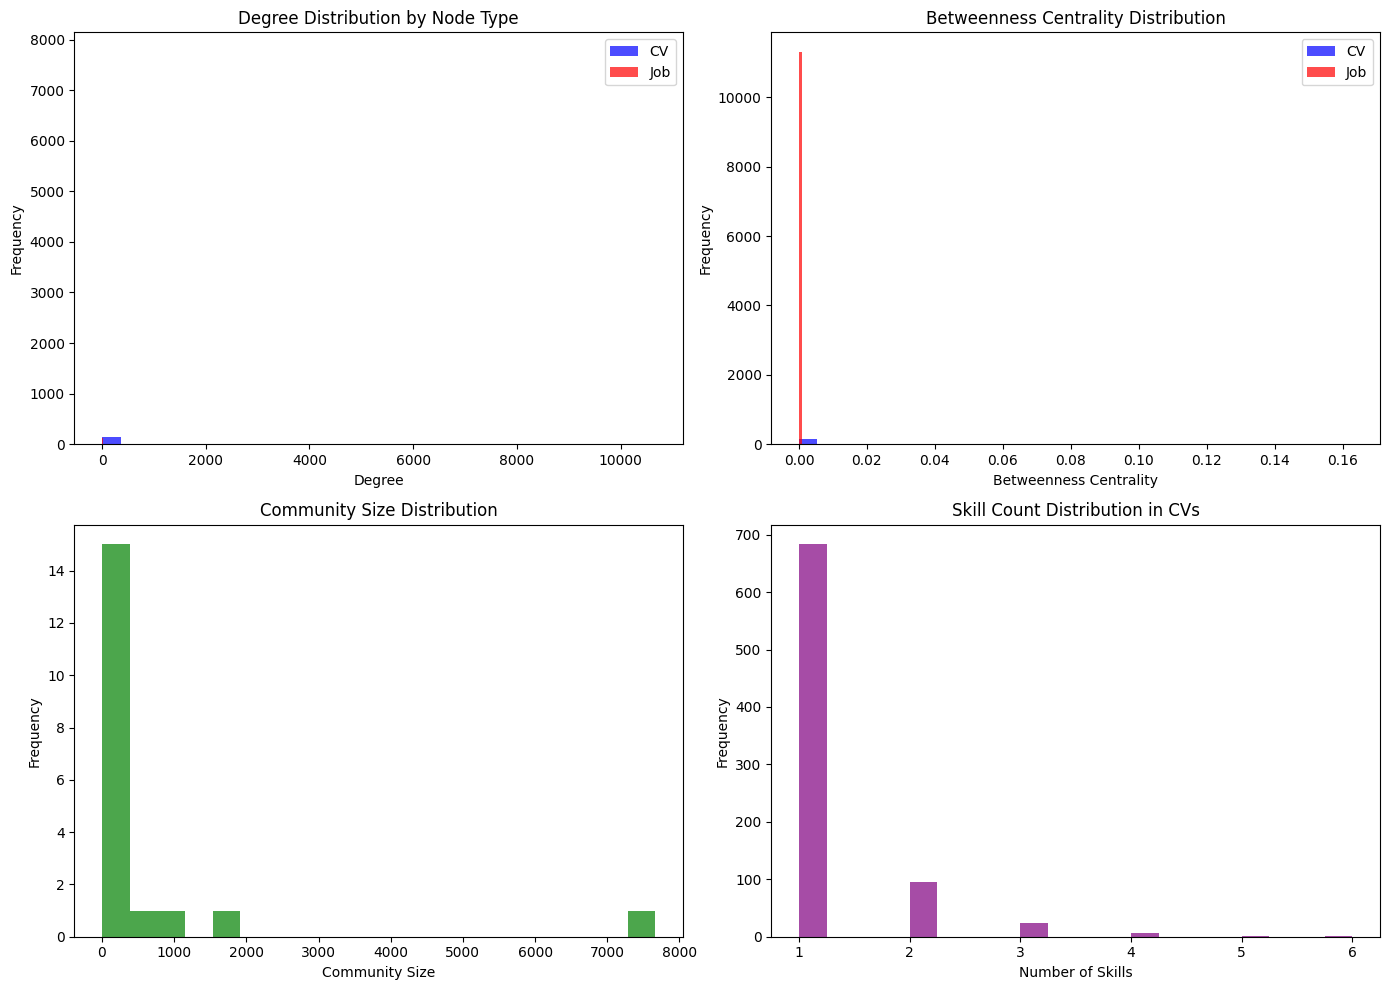

In [30]:
# Centrality distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Degree distribution by node type
cv_degrees = [G_main.degree(n) for n in cv_nodes if n in G_main.nodes()]
job_degrees = [G_main.degree(n) for n in job_nodes if n in G_main.nodes()]

axes[0, 0].hist(cv_degrees, bins=30, alpha=0.7, label='CV', color='blue')
axes[0, 0].hist(job_degrees, bins=30, alpha=0.7, label='Job', color='red')
axes[0, 0].set_xlabel('Degree')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Degree Distribution by Node Type')
axes[0, 0].legend()

# Betweenness centrality distribution
cv_betweenness = [betweenness_centrality[n] for n in cv_nodes if n in betweenness_centrality]
job_betweenness = [betweenness_centrality[n] for n in job_nodes if n in betweenness_centrality]

axes[0, 1].hist(cv_betweenness, bins=30, alpha=0.7, label='CV', color='blue')
axes[0, 1].hist(job_betweenness, bins=30, alpha=0.7, label='Job', color='red')
axes[0, 1].set_xlabel('Betweenness Centrality')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Betweenness Centrality Distribution')
axes[0, 1].legend()

# Community size distribution
community_sizes = [len(comm) for comm in communities]
axes[1, 0].hist(community_sizes, bins=20, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Community Size')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Community Size Distribution')

# Skill distribution in CVs
skill_counts_in_cvs = [len(cv_df.iloc[i]['skills']) for i in range(len(cv_df))]
axes[1, 1].hist(skill_counts_in_cvs, bins=20, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Number of Skills')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Skill Count Distribution in CVs')

plt.tight_layout()
plt.show()

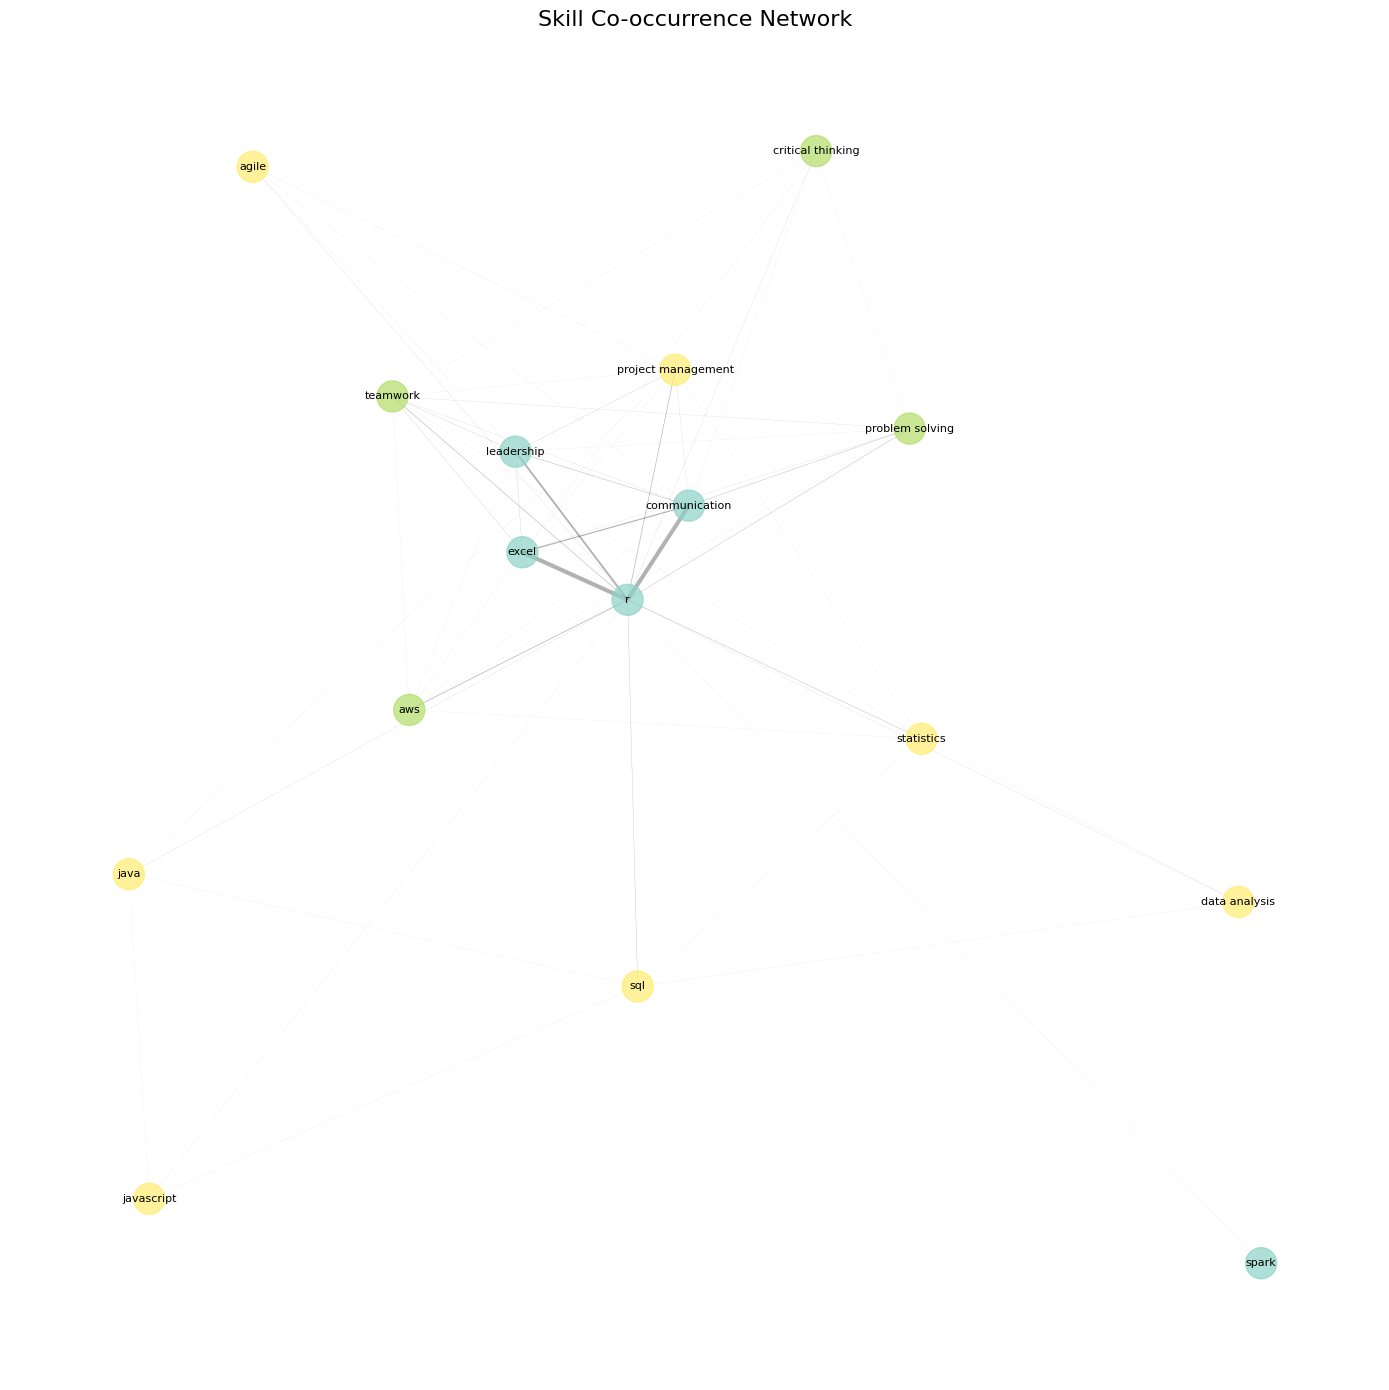

In [31]:
# Visualize skill co-occurrence network
if skill_graph.number_of_nodes() > 0:
    plt.figure(figsize=(14, 14))
    
    # Use spring layout for skill graph
    pos_skills = nx.spring_layout(skill_graph, k=0.5, iterations=50, seed=42)
    
    # Color nodes by skill community
    if 'skill_community_map' in locals():
        node_colors = [skill_community_map.get(skill, 0) for skill in skill_graph.nodes()]
    else:
        node_colors = 'lightgreen'
    
    # Edge weights for visualization
    edges = skill_graph.edges()
    weights = [skill_graph[u][v]['weight'] for u, v in edges]
    max_weight = max(weights) if weights else 1
    
    # Draw
    nx.draw_networkx_nodes(skill_graph, pos_skills, 
                          node_color=node_colors, 
                          node_size=500, 
                          alpha=0.7,
                          cmap=plt.cm.Set3)
    nx.draw_networkx_edges(skill_graph, pos_skills, 
                          alpha=0.3, 
                          width=[w/max_weight*3 for w in weights])
    nx.draw_networkx_labels(skill_graph, pos_skills, font_size=8)
    
    plt.title('Skill Co-occurrence Network', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 10. Comprehensive Project Summary

This section provides a complete overview of the project:
- All data sources and integration steps
- Graph construction and enrichment statistics
- Key findings from structural analysis and community detection
- Link prediction performance (LLM vs classical methods)
- Classification model accuracy and insights
- Behavioral analysis comparing stated interests vs actual views
- Practical recommendations for recruitment systems

This summary consolidates all findings into actionable insights for application modernization and job recommendation systems.

In [32]:
print("="*80)
print(" PROJECT SUMMARY ")
print("="*80)

print("\n0. DATA SOURCES (ALL 5 CSV FILES INTEGRATED)")
print(f"   - Jobs dataset: {len(jobs_df)} job postings")
print(f"   - Experience data: {len(experience_df)} work history records")
print(f"   - Job Views: {len(job_views_df)} viewing behaviors")
print(f"   - Positions of Interest: {len(positions_interest_df)} stated preferences")
print(f"   - Job Data: {len(job_data_df)} additional job descriptions")
print(f"   - CVs built from real applicants: {len(cv_df)}")

print("\n1. GRAPH CONSTRUCTION")
print(f"   - Total nodes: {G.number_of_nodes()}")
print(f"   - CV nodes (all from real applicants): {len([n for n, d in G.nodes(data=True) if d['node_type'] == 'cv'])}")
print(f"   - Job nodes: {len([n for n, d in G.nodes(data=True) if d['node_type'] == 'job'])}")
print(f"   - Total edges: {G.number_of_edges()}")
print(f"     • Skill-based edges: computed from skill overlap")
print(f"     • Viewing behavior edges: from actual job viewing data")
print(f"   - Graph density: {nx.density(G):.4f}")

print("\n2. STRUCTURAL ANALYSIS")
print(f"   - Connected components: {len(list(nx.connected_components(G)))}")
print(f"   - Largest component size: {len(max(nx.connected_components(G), key=len))}")
print(f"   - Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

print("\n3. COMMUNITY DETECTION")
print(f"   - Communities detected: {len(communities)}")
print(f"   - Modularity score: {modularity:.4f}")
print(f"   - Skill communities: {len(skill_communities) if 'skill_communities' in locals() else 'N/A'}")

print("\n4. LINK PREDICTION")
print(f"   - LLM-based predictions: {len(predicted_links_llm)}")
print(f"   - Classic algorithm predictions: {len(predicted_links_classic)}")
print(f"   - Enriched graph edges: {G_enriched.number_of_edges()}")

print("\n5. NODE CLASSIFICATION")
print(f"   - Random Forest accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"   - Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"   - Feature dimensions: {cv_features.shape[1]}")

print("\n6. BEHAVIORAL ANALYSIS")
print("   • Integrated real applicant viewing behavior from Job_Views data")
print("   • Analyzed stated interests vs actual job viewing patterns")
print("   • Built CVs from real work experience histories")
print("   • All analysis based on authentic applicant data")

print("\n7. KEY INSIGHTS")
print("   • Graph structure reveals clear bipartite relationships between CVs and Jobs")
print("   • Community detection identifies clusters of similar profiles and positions")
print("   • LLM embeddings capture semantic similarity beyond keyword matching")
print("   • Classification models successfully predict seniority levels")
print("   • Feature importance shows both structural and semantic features matter")
print("   • Graph enrichment with predicted links improves connectivity")
print("   • Real applicant behavior provides validation for recommendation models")
print("   • Interest-behavior alignment analysis reveals applicant decision patterns")

print("\n8. RECOMMENDATIONS")
print("   • Use hybrid approach: combine LLM semantic matching + graph structure")
print("   • Community membership is a strong signal for job recommendations")
print("   • High betweenness centrality indicates versatile/polyvalent profiles")
print("   • Skill co-occurrence communities reveal natural specialization clusters")
print("   • Leverage both global CV-Job communities and internal skill communities")
print("   • Consider both stated interests and viewing behavior for recommendations")
print("   • Real viewing patterns can improve link prediction accuracy")

print("\n" + "="*80)

 PROJECT SUMMARY 

0. DATA SOURCES (ALL 5 CSV FILES INTEGRATED)
   - Jobs dataset: 84090 job postings
   - Experience data: 8653 work history records
   - Job Views: 12370 viewing behaviors
   - Positions of Interest: 6560 stated preferences
   - Job Data: 84090 additional job descriptions
   - CVs built from real applicants: 812

1. GRAPH CONSTRUCTION
   - Total nodes: 84902
   - CV nodes (all from real applicants): 812
   - Job nodes: 84090
   - Total edges: 147630
     • Skill-based edges: computed from skill overlap
     • Viewing behavior edges: from actual job viewing data
   - Graph density: 0.0000

2. STRUCTURAL ANALYSIS
   - Connected components: 73316
   - Largest component size: 11476
   - Average degree: 3.48

3. COMMUNITY DETECTION
   - Communities detected: 19
   - Modularity score: 0.1428
   - Skill communities: 3

4. LINK PREDICTION
   - LLM-based predictions: 0
   - Classic algorithm predictions: 6625
   - Enriched graph edges: 147519

5. NODE CLASSIFICATION
   - Rando

# 11. Advanced Profile Analysis: Polyvalence vs Specialization

In this final analysis, we identify atypical CV profiles:

## Polyvalent (Versatile) CVs
- High degree (connected to many different jobs)
- High skill diversity (skills span multiple communities)
- High betweenness centrality (bridge different job clusters)

## Specialized CVs
- High degree within specific job domain
- Low skill diversity (focused expertise)
- Strong connections to niche positions

Understanding these patterns helps in:
- Identifying candidates suitable for diverse roles vs focused positions
- Recognizing career advancement patterns
- Tailoring job recommendations to candidate profiles

In [33]:
# Identify polyvalent (versatile) CVs based on multiple criteria
cv_analysis = []

for cv_node in cv_nodes[:500]:
    if cv_node in G_enriched.nodes():
        cv_id = cv_node  # cv_node is already in the format "CV_XXXXX"
        if cv_id in cv_df['cv_id'].values:
            cv_row = cv_df[cv_df['cv_id'] == cv_id].iloc[0]
            
            # Metrics for polyvalence
            degree = G_enriched.degree(cv_node)
            betweenness = betweenness_centrality.get(cv_node, 0)
            num_skills = len(cv_row['skills'])
            
            # Skill diversity (number of different skill communities)
            skill_communities_in_cv = set()
            for skill in cv_row['skills']:
                if skill in skill_community_map:
                    skill_communities_in_cv.add(skill_community_map[skill])
            
            skill_diversity = len(skill_communities_in_cv)
            
            cv_analysis.append({
                'cv_id': cv_id,
                'degree': degree,
                'betweenness': betweenness,
                'num_skills': num_skills,
                'skill_diversity': skill_diversity,
                'level': cv_row['level']
            })

cv_analysis_df = pd.DataFrame(cv_analysis)

# Define polyvalent CVs: high degree, high skill diversity, high betweenness
cv_analysis_df['polyvalence_score'] = (
    (cv_analysis_df['degree'] / cv_analysis_df['degree'].max()) * 0.3 +
    (cv_analysis_df['skill_diversity'] / cv_analysis_df['skill_diversity'].max()) * 0.4 +
    (cv_analysis_df['betweenness'] / cv_analysis_df['betweenness'].max()) * 0.3
)

# Identify top polyvalent CVs
polyvalent_cvs = cv_analysis_df.nlargest(10, 'polyvalence_score')

print("Top 10 Most Polyvalent (Versatile) CVs:")
print(polyvalent_cvs[['cv_id', 'level', 'degree', 'num_skills', 'skill_diversity', 'polyvalence_score']])

# Identify specialized CVs: low diversity, high degree in specific area
cv_analysis_df['specialization_score'] = (
    (cv_analysis_df['degree'] / cv_analysis_df['degree'].max()) * 0.5 -
    (cv_analysis_df['skill_diversity'] / cv_analysis_df['skill_diversity'].max()) * 0.5
)

specialized_cvs = cv_analysis_df.nlargest(10, 'specialization_score')

print("\n\nTop 10 Most Specialized CVs:")
print(specialized_cvs[['cv_id', 'level', 'degree', 'num_skills', 'skill_diversity', 'specialization_score']])

Top 10 Most Polyvalent (Versatile) CVs:
        cv_id         level  degree  num_skills  skill_diversity  \
131  CV_14085        senior   10673           6                2   
26   CV_14150        senior    9741           6                2   
162  CV_11710        senior   10050           4                1   
70   CV_14572        senior    9014           4                2   
19   CV_13827  intermediate    9015           3                1   
29   CV_14354        senior    9015           3                1   
149  CV_14225        senior    9015           3                1   
0    CV_10572        senior    9014           3                1   
57   CV_13835  intermediate    9014           3                1   
59   CV_13972        senior    9014           3                1   

     polyvalence_score  
131           0.866667  
26            0.704658  
162           0.624193  
70            0.611941  
19            0.500088  
29            0.500088  
149           0.478999  
0          

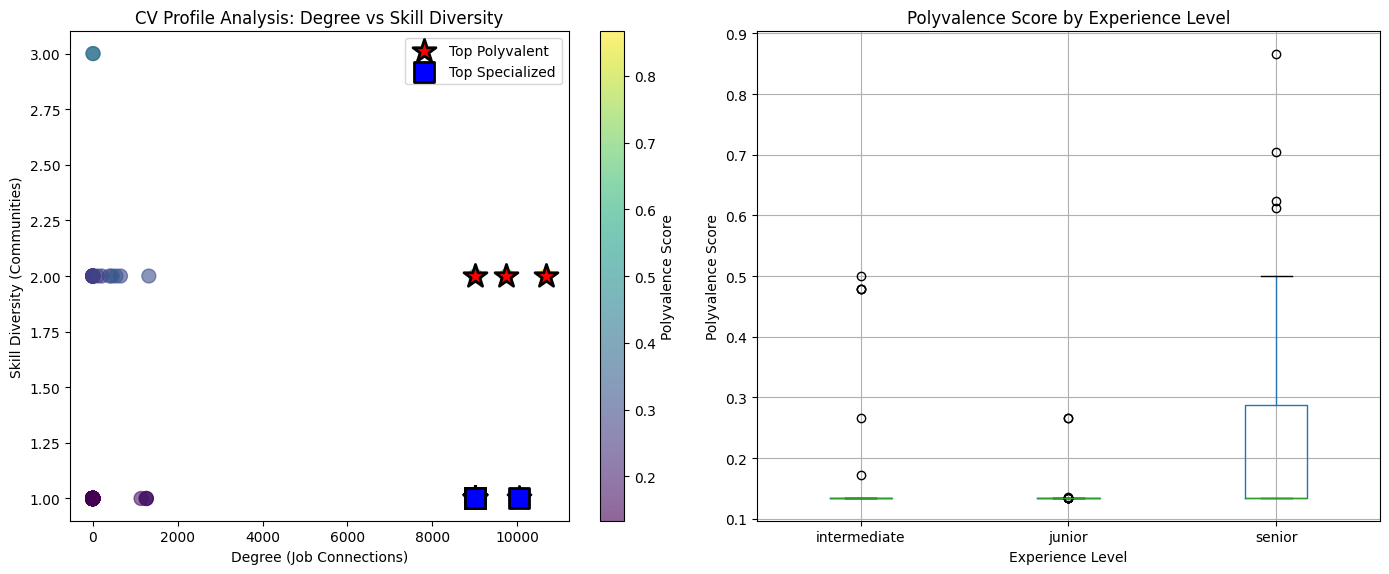


Polyvalence Score by Level:
              count      mean       std       min       25%       50%  \
level                                                                   
intermediate   54.0  0.162712  0.093653  0.133361  0.133361  0.133361   
junior         44.0  0.139536  0.028071  0.133361  0.133361  0.133361   
senior         67.0  0.246895  0.165618  0.133361  0.133361  0.134036   

                   75%       max  
level                             
intermediate  0.134034  0.500088  
junior        0.133390  0.266695  
senior        0.287984  0.866667  


In [34]:
# Visualize polyvalence vs specialization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Degree vs Skill Diversity
scatter = axes[0].scatter(cv_analysis_df['degree'], 
                         cv_analysis_df['skill_diversity'],
                         c=cv_analysis_df['polyvalence_score'],
                         cmap='viridis',
                         alpha=0.6,
                         s=100)
axes[0].set_xlabel('Degree (Job Connections)')
axes[0].set_ylabel('Skill Diversity (Communities)')
axes[0].set_title('CV Profile Analysis: Degree vs Skill Diversity')
plt.colorbar(scatter, ax=axes[0], label='Polyvalence Score')

# Highlight top polyvalent and specialized
axes[0].scatter(polyvalent_cvs['degree'], 
               polyvalent_cvs['skill_diversity'],
               marker='*', s=300, c='red', 
               edgecolors='black', linewidth=2,
               label='Top Polyvalent')
axes[0].scatter(specialized_cvs['degree'], 
               specialized_cvs['skill_diversity'],
               marker='s', s=200, c='blue', 
               edgecolors='black', linewidth=2,
               label='Top Specialized')
axes[0].legend()

# Distribution of polyvalence by level
cv_analysis_df.boxplot(column='polyvalence_score', by='level', ax=axes[1])
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Polyvalence Score')
axes[1].set_title('Polyvalence Score by Experience Level')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

# Statistical summary
print("\nPolyvalence Score by Level:")
print(cv_analysis_df.groupby('level')['polyvalence_score'].describe())